In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
import joblib
import os

In [2]:
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('../data/processed/df_master_clustered.csv')

In [4]:
print(f"Datos cargados: {df.shape}")
print(f"Distribución de Tiers (Clases a predecir):\n{df['tier'].value_counts().sort_index()}")

Datos cargados: (28370, 15)
Distribución de Tiers (Clases a predecir):
tier
1     5502
2     4066
3     8739
4    10063
Name: count, dtype: int64


In [5]:
print("\n--- REALIDAD DE MERCADO: MEDIANA DE PRECIOS POR TIER ---")
print(df.groupby('tier')['price'].median().to_frame(name='Mediana Precio ($)'))


--- REALIDAD DE MERCADO: MEDIANA DE PRECIOS POR TIER ---
      Mediana Precio ($)
tier                    
1                 7900.0
2                 8500.0
3                21000.0
4                36000.0


In [6]:
y = df['tier']
X = df.drop(columns=['price', 'tier', 'cluster_raw', 'tier_cat'], errors='ignore')

In [7]:
numeric_features = ['year', 'odometer', 'cylinders_num']
categorical_features = ['manufacturer', 'model', 'fuel', 'drive', 'transmission', 'type', 'paint_color', 'condition']

In [8]:
categorical_features = [col for col in categorical_features if col in X.columns]

print("\n--- CONFIGURACIÓN DEL MODELO ---")
print(f"Variables Numéricas ({len(numeric_features)}): {numeric_features}")
print(f"Variables Categóricas ({len(categorical_features)}): {categorical_features}")


--- CONFIGURACIÓN DEL MODELO ---
Variables Numéricas (3): ['year', 'odometer', 'cylinders_num']
Variables Categóricas (8): ['manufacturer', 'model', 'fuel', 'drive', 'transmission', 'type', 'paint_color', 'condition']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nEntrenando con: {X_train.shape[0]} coches")
print(f"Validando con:  {X_test.shape[0]} coches")


Entrenando con: 22696 coches
Validando con:  5674 coches


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Usamos RandomForest. Es robusto y no requiere tanta afinación como una red neuronal.
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42))
])

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

In [14]:
print(f"Scores por fold: {scores}")
print(f"ACCURACY PROMEDIO: {scores.mean():.2%} (+/- {scores.std()*2:.2%})")

Scores por fold: [0.96968629 0.96774762 0.97232993 0.97514981 0.97197744]
ACCURACY PROMEDIO: 97.14% (+/- 0.50%)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

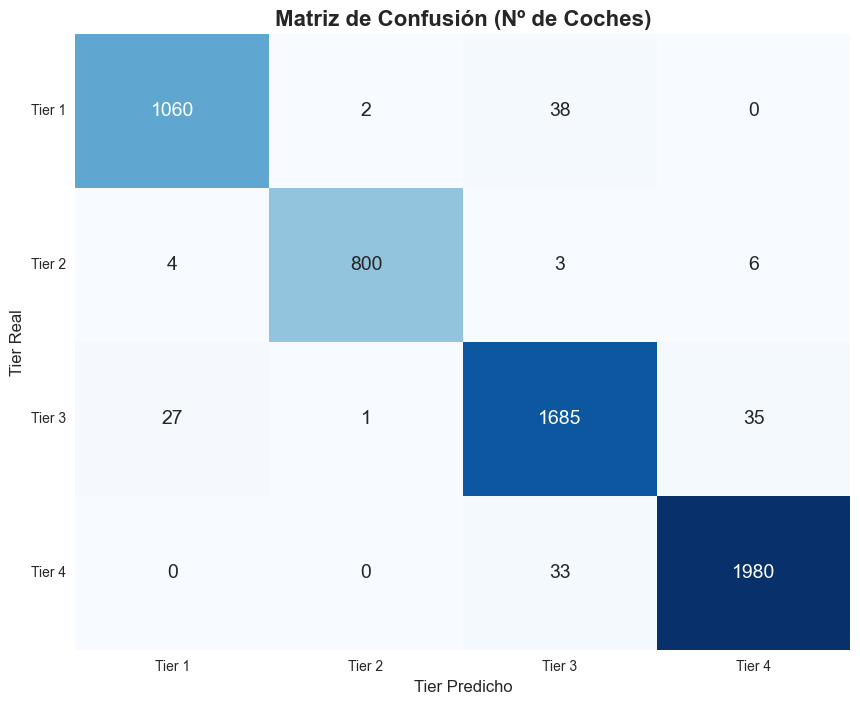

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title('Matriz de Confusión (Nº de Coches)', fontsize=16, fontweight='bold')
plt.ylabel('Tier Real', fontsize=12)
plt.xlabel('Tier Predicho', fontsize=12)
# Ajustamos etiquetas si son 1,2,3,4
plt.xticks(ticks=np.arange(4)+0.5, labels=['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'])
plt.yticks(ticks=np.arange(4)+0.5, labels=['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'], rotation=0)
plt.show()

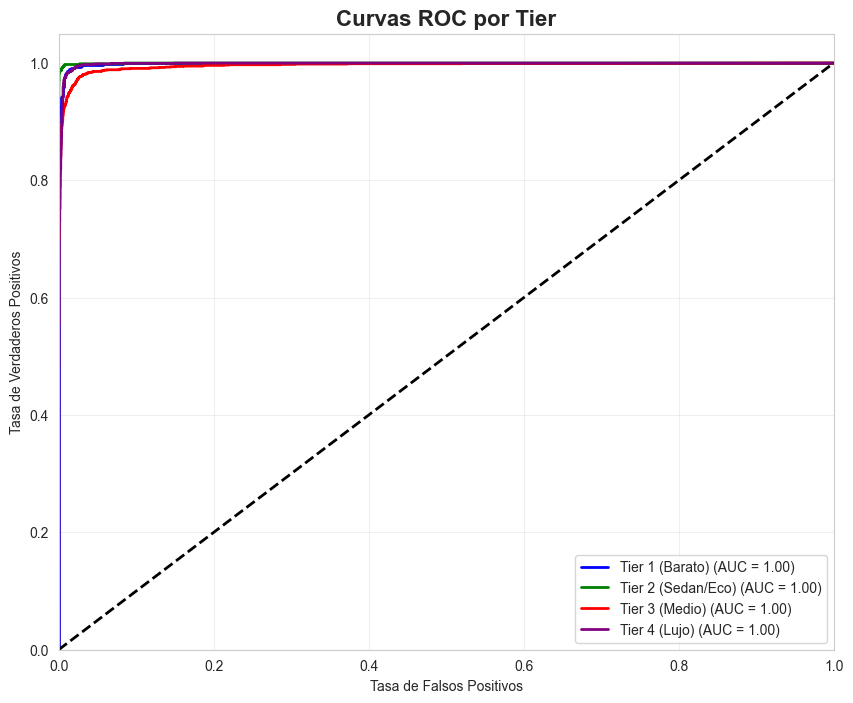

In [17]:
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
y_score = model.predict_proba(X_test) # Probabilidades

n_classes = y_test_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple']
tier_names = ['Tier 1 (Barato)', 'Tier 2 (Sedan/Eco)', 'Tier 3 (Medio)', 'Tier 4 (Lujo)']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{tier_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por Tier', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

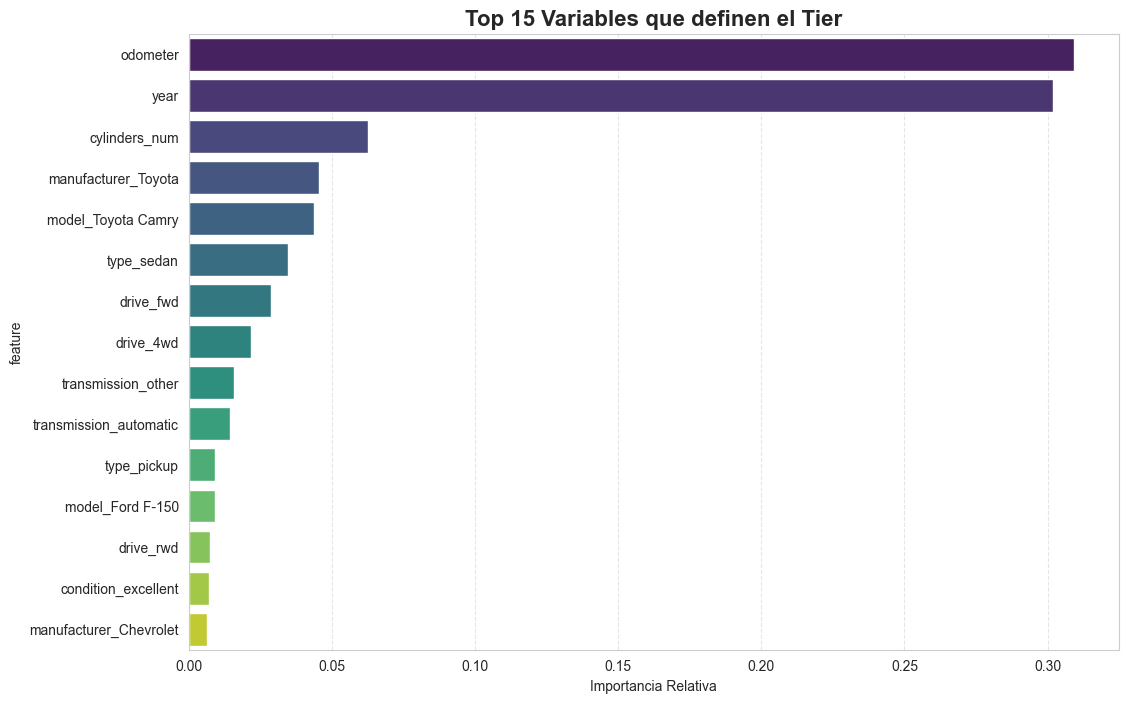

In [18]:
try:
    # Extraer nombres de columnas tras el OneHotEncoder
    ohe = model.named_steps['preprocessor'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(cat_names)

    # Extraer importancia del Random Forest
    importances = model.named_steps['classifier'].feature_importances_

    # Crear DataFrame y ordenar
    df_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
    df_imp = df_imp.sort_values('importance', ascending=False).head(15) # Top 15

    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')
    plt.title('Top 15 Variables que definen el Tier', fontsize=16, fontweight='bold')
    plt.xlabel('Importancia Relativa')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()

except Exception as e:
    print(f"No se pudo generar el gráfico de importancia: {e}")

In [20]:
tier_stats = {}

for tier_id in sorted(df['tier'].unique()):
    # Filtramos los coches de este Tier
    subset = df[df['tier'] == tier_id]

    # Guardamos estadísticas clave
    tier_stats[tier_id] = {
        'min_price': int(subset['price'].quantile(0.05)), # Usamos percentil 5 para evitar outliers bajos
        'max_price': int(subset['price'].quantile(0.95)), # Usamos percentil 95 para evitar outliers altos
        'median_price': int(subset['price'].median()),
        'count': len(subset),
        'description': f"Gama {tier_id}" # Puedes personalizar esto luego
    }

print("Diccionario generado:")
print(tier_stats)

Diccionario generado:
{np.int64(1): {'min_price': 2250, 'max_price': 14988, 'median_price': 7900, 'count': 5502, 'description': 'Gama 1'}, np.int64(2): {'min_price': 2200, 'max_price': 23981, 'median_price': 8500, 'count': 4066, 'description': 'Gama 2'}, np.int64(3): {'min_price': 10995, 'max_price': 31753, 'median_price': 21000, 'count': 8739, 'description': 'Gama 3'}, np.int64(4): {'min_price': 24900, 'max_price': 54241, 'median_price': 36000, 'count': 10063, 'description': 'Gama 4'}}


In [ ]:
path_metadata = '../models/tier_metadata.pkl'
joblib.dump(tier_stats, path_metadata)
print(f"✅ Metadatos de precios guardados en: {path_metadata}")

In [21]:
path_model = '../models/tier_classifier.pkl'
os.makedirs(os.path.dirname(path_model), exist_ok=True)
joblib.dump(model, path_model)
print(f"✅ Modelo guardado en: {path_model}")

✅ Metadatos de precios guardados en: ../models/tier_metadata.pkl
